# HFR calibration — static model
Calibrate the undetermined ohmic-resistance parameters of the 1D static PEMFC model by fitting the simulated HFR to the experimental HFR measurements. Compare the calibration outcome across four experimental subsets (one condition / fixed pressure / fixed temperature / all data).

In [1]:
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import optuna
from optuna.pruners import MedianPruner
from copy import deepcopy
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")


In [2]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024"
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
# --------------- Import custom modules  --------------- #
import model.static as static_module
from model.static import PEMFC_stat
from model.coefficients import *
from config.initialize import *
from config.settings import *


## Calibration setup

In [3]:
# Tested currents and the (T, P, RHC) grid we sweep over.
I_tested   = [10, 20, 30, 40, 50]
RHC_tested = [0, 50]
PAC_tested = [1.3e5, 1.4e5, 1.5e5]
TFC_tested = [50, 60, 70]


### Experiment data import

In [4]:
# Load the HFR experimental data. Each sheet name is "T{C}_P{mbar_gauge}_HRC{%}".
# The R column stores a "(R, I)" tuple as a string -- pull out the float R.
hfr_data_path = project_root / "data" / "HFR.xlsx"
hfr_testdata  = pd.read_excel(hfr_data_path, sheet_name=None)
hfrdata_exp   = {}
for sheet_name, raw in hfr_testdata.items():
    parsed = raw["R"].str.strip("()").str.split(",", expand=True).astype(float)
    hfrdata_exp[sheet_name] = pd.DataFrame({"I_LOAD": raw["I_LOAD"], "R": parsed[0]})
print(f"Loaded {len(hfrdata_exp)} HFR sheets: {list(hfrdata_exp.keys())}")


Loaded 12 HFR sheets: ['T50_P300_HRC0', 'T50_P300_HRC50', 'T50_P400_HRC50', 'T50_P500_HRC50', 'T60_P300_HRC0', 'T60_P300_HRC50', 'T60_P400_HRC50', 'T60_P500_HRC50', 'T70_P300_HRC0', 'T70_P300_HRC50', 'T70_P400_HRC50', 'T70_P500_HRC50']


### Define `hfrtest_sim` and the objective factory

In [5]:
def hfrtest_sim(parameters, cond_filter=None):
    """Run the static model and return ``{cond_key: [HFR at I_tested]}`` in
    Ohm.m^2 per cell (HFR = ohmic resistance, i.e. sum(Rmem) + Re inside
    ``sol['Rohm']``). Returns ``False`` if any HFR was non-finite.

    Pass ``cond_filter(T, P, RHC) -> bool`` to restrict which conditions
    are simulated.
    """
    result = {}
    for RHC in RHC_tested:
        for P_des in PAC_tested:
            for T_des in TFC_tested:
                cond_key = "T" + str(T_des) + "_P" + str(int(P_des/1e2 - 1e3)) + "_HRC" + str(RHC)
                if cond_key not in hfrdata_exp:
                    continue
                if cond_filter is not None and not cond_filter(T_des, P_des, RHC):
                    continue

                # The static module reads Pa_des / Pc_des from module-level globals.
                static_module.Pa_des = P_des
                static_module.Pc_des = P_des
                op_stat = {
                    "Tfc": T_des + 273.15, "Phi_a_des": RHC / 100, "Phi_c_des": RHC / 100,
                    "Pa_des": P_des, "Pc_des": P_des,
                    "Win_c": parameters.get("Win_c", 4.8),
                    "Wout_c": parameters.get("Wout_c", 21.0),
                    "Win_a": parameters.get("Win_a", 4.8),
                    "Wout_a": parameters.get("Wout_a", 4.8),
                }
                model = PEMFC_stat(parameters, op_stat)
                hfr_test = []
                for I_LOAD in I_tested:
                    try:
                        sol = model.solve(I_LOAD / parameters["Aact"])
                    except Exception:
                        return False
                    hfr_test.append(sol["Rohm"])
                    if not math.isfinite(sol["Rohm"]):
                        return False
                result[cond_key] = hfr_test
    return result


In [6]:
def _experimental_hfr(cond_key):
    """Look up the experimental HFR at every I_tested for one condition.
    The Excel sheets store R as a "(R, I)" string in mOhm at the stack level;
    convert to Ohm.m^2 per cell:  R[mOhm] * 1e-3 / n_cell * Aact.
    """
    df = hfrdata_exp[cond_key]
    i_exp = df["I_LOAD"].to_numpy(dtype=float)
    r_exp = df["R"].to_numpy(dtype=float) * 1e-3 / n_cell * parameters["Aact"]
    idx = [np.argmin((i_test - i_exp) ** 2) for i_test in I_tested]
    return r_exp[idx]


def make_objective(cond_filter):
    """Return an optuna objective that fits only the conditions selected by
    ``cond_filter`` -- so a single objective function can be reused across
    the four calibration scenarios."""
    def objective(trial):
        params_trial = deepcopy(parameters)

        params_trial["Re"]          = trial.suggest_float("Re",          1e-7, 5e-6, log=True)
        params_trial["epsilon_gdl"] = trial.suggest_float("epsilon_gdl", 0.5,  0.8)
        params_trial["epsilon_mc"]  = trial.suggest_float("epsilon_mc",  0.15, 0.4)
        params_trial["epsilon_cl"]  = trial.suggest_float("epsilon_cl",  0.1,  0.4)
        params_trial["epsilon_c"]   = trial.suggest_float("epsilon_c",   0.2,  0.3)
        params_trial["tau"]         = trial.suggest_float("tau",         1.0,  4.0)
        params_trial["Hgdl"]        = trial.suggest_float("Hgdl",        2e-4, 4e-4, log=True)
        params_trial["Hcl"]         = trial.suggest_float("Hcl",         1e-5, 2e-5, log=True)
        params_trial["Wout_c"]      = trial.suggest_float("Wout_c",      7.0,  22.0)
        params_trial["Wout_a"]      = trial.suggest_float("Wout_a",      5.0,  8.0)

        try:
            sim = hfrtest_sim(params_trial, cond_filter=cond_filter)
        except Exception:
            return 1e6
        if sim is False or not sim:
            return 1e6

        error = 0.0
        for cond_key, r_sim in sim.items():
            r_exp = _experimental_hfr(cond_key)
            error += float(np.sum((np.array(r_sim) - r_exp) ** 2))
        return error
    return objective


## Calibration scenarios

In [7]:
# Anchor conditions for the partial calibration scenarios -- edit if you
# want different subsets. Defaults are picked so each scenario maps to at
# least one condition present in the experimental dataset.
SINGLE_T   = 60       # degrees C
SINGLE_P   = 1.4e5    # Pa
SINGLE_RHC = 50       # %         (RHC=0 is only available at P=1.3 bar)
TWO_HUM_T  = 50       # degrees C -- scenario "two humidifications"
TWO_HUM_P  = 1.3e5    # Pa        -- (RHC=0 and RHC=50 are both available at P=1.3 bar)
FIXED_P    = 1.3e5    # Pa  -- scenario "fixed pressure"
FIXED_T    = 60       # degrees C -- scenario "fixed temperature"

scenarios = {
    "one_condition":      {
        "label":  f"One condition (T={SINGLE_T}, P={SINGLE_P/1e5:.1f} bar, RHC={SINGLE_RHC})",
        "filter": lambda T, P, RHC: (T == SINGLE_T) and (P == SINGLE_P) and (RHC == SINGLE_RHC),
    },
    "two_humidification": {
        "label":  f"Two humidifications (P={TWO_HUM_P/1e5:.1f} bar, T={TWO_HUM_T}, RHC in {{0, 50}})",
        "filter": lambda T, P, RHC: (T == TWO_HUM_T) and (P == TWO_HUM_P) and (RHC in (0, 50)),
    },
    "fixed_pressure":     {
        "label":  f"Fixed pressure (P={FIXED_P/1e5:.1f} bar, all T, all RHC)",
        "filter": lambda T, P, RHC: P == FIXED_P,
    },
    "fixed_temperature":  {
        "label":  f"Fixed temperature (T={FIXED_T}, all P, all RHC)",
        "filter": lambda T, P, RHC: T == FIXED_T,
    },
    "all_data":           {
        "label":  "All conditions",
        "filter": lambda T, P, RHC: True,
    },
}


def conditions_in_scenario(filter_fn):
    """Return the cond_keys present in the experimental data that pass the filter."""
    keys = []
    for RHC in RHC_tested:
        for P_des in PAC_tested:
            for T_des in TFC_tested:
                cond_key = "T" + str(T_des) + "_P" + str(int(P_des/1e2 - 1e3)) + "_HRC" + str(RHC)
                # Look up against whichever experimental-data dict this notebook uses.
                exp_data = globals().get("polardata_exp") or globals().get("hfrdata_exp") or {}
                if cond_key in exp_data and filter_fn(T_des, P_des, RHC):
                    keys.append(cond_key)
    return keys


for name, info in scenarios.items():
    matches = conditions_in_scenario(info["filter"])
    print(f"  {name:20s}  {len(matches):2d} conditions  -> {matches}")


  one_condition          1 conditions  -> ['T60_P400_HRC50']
  two_humidification     2 conditions  -> ['T50_P300_HRC0', 'T50_P300_HRC50']
  fixed_pressure         6 conditions  -> ['T50_P300_HRC0', 'T60_P300_HRC0', 'T70_P300_HRC0', 'T50_P300_HRC50', 'T60_P300_HRC50', 'T70_P300_HRC50']
  fixed_temperature      4 conditions  -> ['T60_P300_HRC0', 'T60_P300_HRC50', 'T60_P400_HRC50', 'T60_P500_HRC50']
  all_data              12 conditions  -> ['T50_P300_HRC0', 'T60_P300_HRC0', 'T70_P300_HRC0', 'T50_P300_HRC50', 'T60_P300_HRC50', 'T70_P300_HRC50', 'T50_P400_HRC50', 'T60_P400_HRC50', 'T70_P400_HRC50', 'T50_P500_HRC50', 'T60_P500_HRC50', 'T70_P500_HRC50']


In [8]:
# Run a separate optuna study per scenario. Static-model trials are
# algebraic and fast -- a short timeout already covers many trials. Total
# wall time ~ (timeout per scenario) * 4.
optuna.logging.set_verbosity(optuna.logging.WARNING)

PER_SCENARIO_TIMEOUT = 180     # seconds
PER_SCENARIO_TRIALS  = 2000
N_JOBS               = 6

results = {}
for name, info in scenarios.items():
    print(f"\n=== Calibrating scenario: {name} ===")
    print(f"    {info['label']}")
    print(f"    conditions used: {conditions_in_scenario(info['filter'])}")
    study = optuna.create_study(direction="minimize")
    study.optimize(
        make_objective(info["filter"]),
        n_trials=PER_SCENARIO_TRIALS,
        timeout=PER_SCENARIO_TIMEOUT,
        n_jobs=N_JOBS,
        show_progress_bar=False,
    )

    params_best = deepcopy(parameters)
    params_best.update(study.best_params)
    sim_all = hfrtest_sim(params_best, cond_filter=None)

    results[name] = {
        "label":           info["label"],
        "calibrated_keys": conditions_in_scenario(info["filter"]),
        "best_params":     study.best_params,
        "best_value":      study.best_value,
        "sim_all":         sim_all if sim_all is not False else {},
    }
    print(f"    best objective on the calibrated subset: {study.best_value:.3e}")



=== Calibrating scenario: one_condition ===
    One condition (T=60, P=1.4 bar, RHC=50)
    conditions used: ['T60_P400_HRC50']
    best objective on the calibrated subset: 3.107e-11

=== Calibrating scenario: two_humidification ===
    Two humidifications (P=1.3 bar, T=50, RHC in {0, 50})
    conditions used: ['T50_P300_HRC0', 'T50_P300_HRC50']
    best objective on the calibrated subset: 7.436e-11

=== Calibrating scenario: fixed_pressure ===
    Fixed pressure (P=1.3 bar, all T, all RHC)
    conditions used: ['T50_P300_HRC0', 'T60_P300_HRC0', 'T70_P300_HRC0', 'T50_P300_HRC50', 'T60_P300_HRC50', 'T70_P300_HRC50']
    best objective on the calibrated subset: 3.421e-10

=== Calibrating scenario: fixed_temperature ===
    Fixed temperature (T=60, all P, all RHC)
    conditions used: ['T60_P300_HRC0', 'T60_P300_HRC50', 'T60_P400_HRC50', 'T60_P500_HRC50']
    best objective on the calibrated subset: 1.367e-10

=== Calibrating scenario: all_data ===
    All conditions
    conditions used:

## Best parameters side-by-side

In [9]:
# Side-by-side parameter comparison.
param_df = pd.DataFrame({name: info["best_params"] for name, info in results.items()})
print(param_df.to_string(float_format=lambda v: f"{v:.4g}"))


             one_condition  two_humidification  fixed_pressure  fixed_temperature  all_data
Re               2.583e-07           2.722e-07       4.283e-06          1.541e-07 3.176e-07
epsilon_gdl         0.7774               0.775           0.688             0.7873    0.7987
epsilon_mc          0.1803              0.1537          0.2805             0.3436     0.158
epsilon_cl          0.3999                 0.4          0.3945             0.3999    0.3986
epsilon_c           0.2048              0.2066          0.2738             0.2424    0.2731
tau                  2.692               2.892           1.104              3.677     2.441
Hgdl             0.0002057           0.0002044       0.0002088          0.0002153 0.0003026
Hcl                  2e-05           1.975e-05       1.969e-05              2e-05 1.972e-05
Wout_c                  22               21.98              22              21.58     21.35
Wout_a               7.941                   8           7.966              7.98

## Compare best-fit HFR curves across scenarios
`plot_scenario_fit(name)` produces two figures per scenario: the fit on the conditions used during calibration, then the fit on every experimental condition.

In [10]:
import math

def plot_scenario_fit(name):
    """For one calibration scenario, show two figures:
    (1) the HFR fit on the conditions USED in the optimisation,
    (2) the HFR fit on ALL conditions.
    Blue solid markers = experiment, red dotted squares = simulation.
    """
    info = results[name]
    cal_set = set(info["calibrated_keys"])

    panels_to_show = [
        ("USED for calibration", info["calibrated_keys"]),
        ("ALL conditions",       list(hfrdata_exp.keys())),
    ]
    for title_suffix, keys in panels_to_show:
        n = len(keys)
        if n == 0:
            print(f"({name}: no conditions for '{title_suffix}')")
            continue
        ncols = min(4, max(1, n))
        nrows = math.ceil(n / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.4 * nrows),
                                 sharex=True, sharey=True, squeeze=False)
        for ax, cond_key in zip(axes.flatten(), keys):
            r_exp = _experimental_hfr(cond_key)
            r_sim = info["sim_all"].get(cond_key)
            ax.plot(I_tested, r_exp, "o-", color="tab:blue",
                    linewidth=1.4, label="experiment")
            if r_sim is not None:
                ax.plot(I_tested, r_sim, "s:", color="tab:red",
                        linewidth=1.2, label="simulated")
            in_cal = cond_key in cal_set
            tag = "[CAL] " if in_cal else ""
            ax.set_title(f"{tag}{cond_key}", fontsize=8,
                         color="tab:green" if in_cal else "black")
            ax.grid(True, alpha=0.3)
        for ax in axes.flatten()[n:]:
            ax.set_visible(False)
        axes.flatten()[0].legend(fontsize=8, loc="best")
        fig.suptitle(f"{info['label']}  --  {title_suffix}\n"
                     f"objective on calibrated subset = {info['best_value']:.3e}",
                     fontsize=10)
        fig.tight_layout()
        plt.show()


### Scenario: `one_condition`

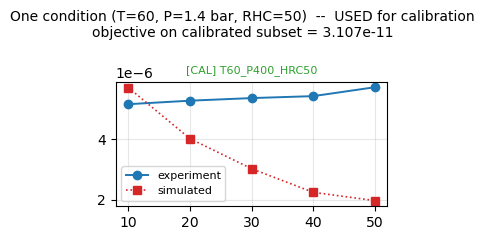

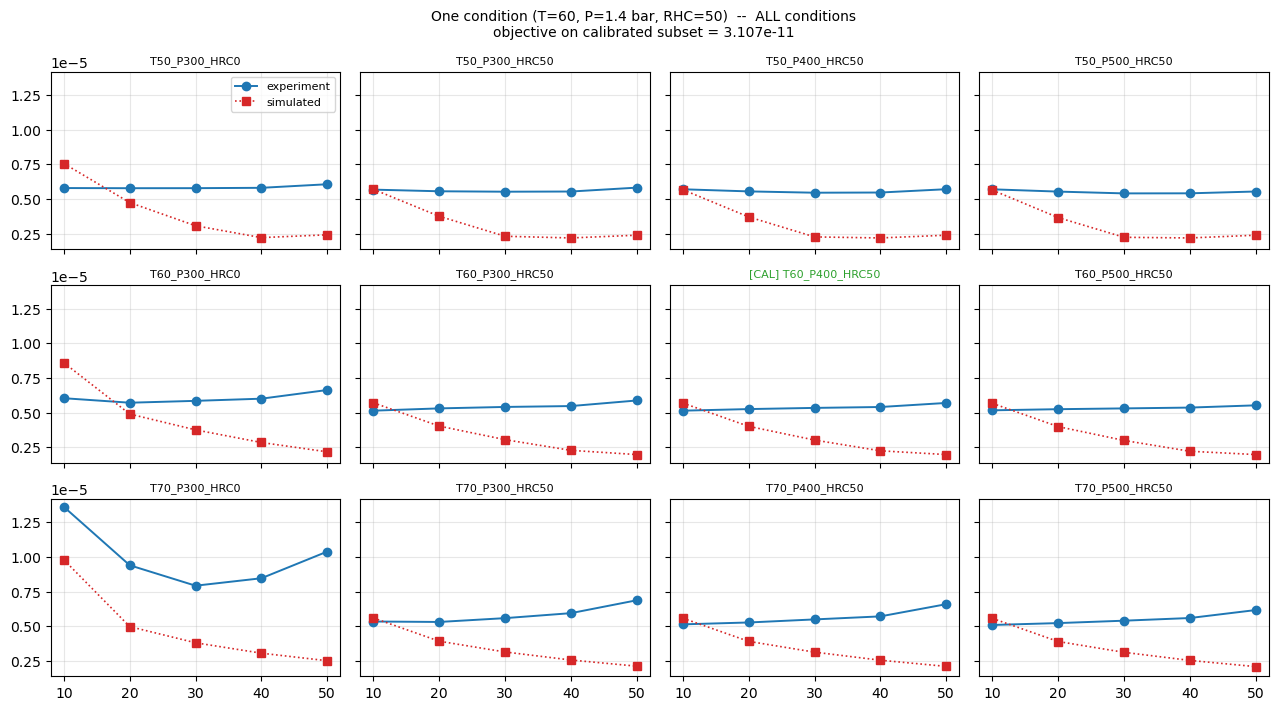

In [11]:
plot_scenario_fit("one_condition")


### Scenario: `two_humidification`
Fit on the two operating conditions that share P and T but differ in cathode humidification (RHC = 0 and 50).


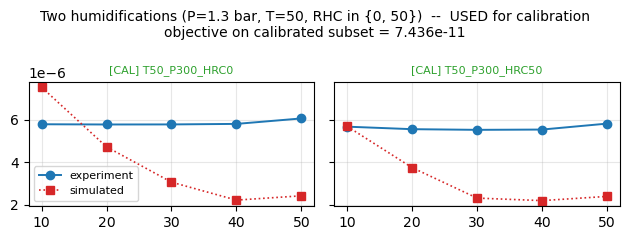

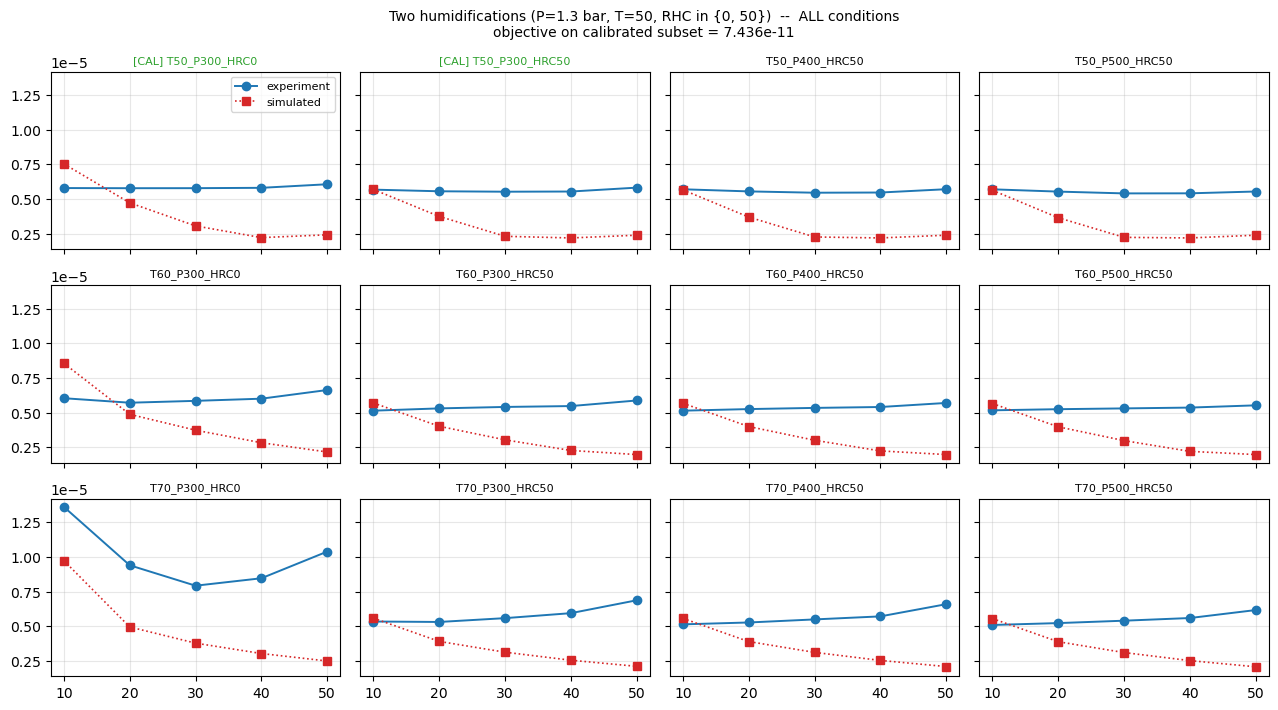

In [12]:
plot_scenario_fit("two_humidification")


### Scenario: `fixed_pressure`

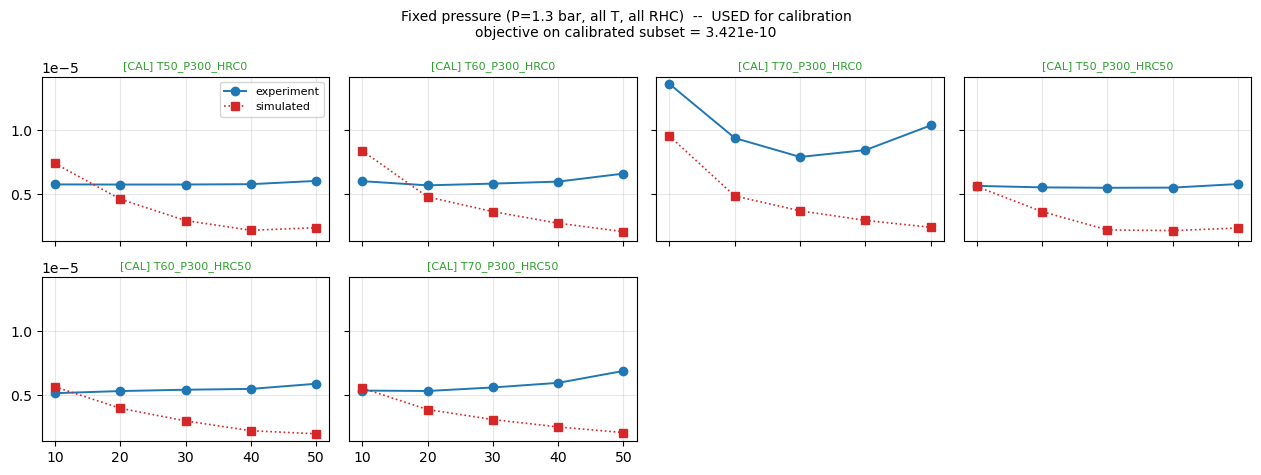

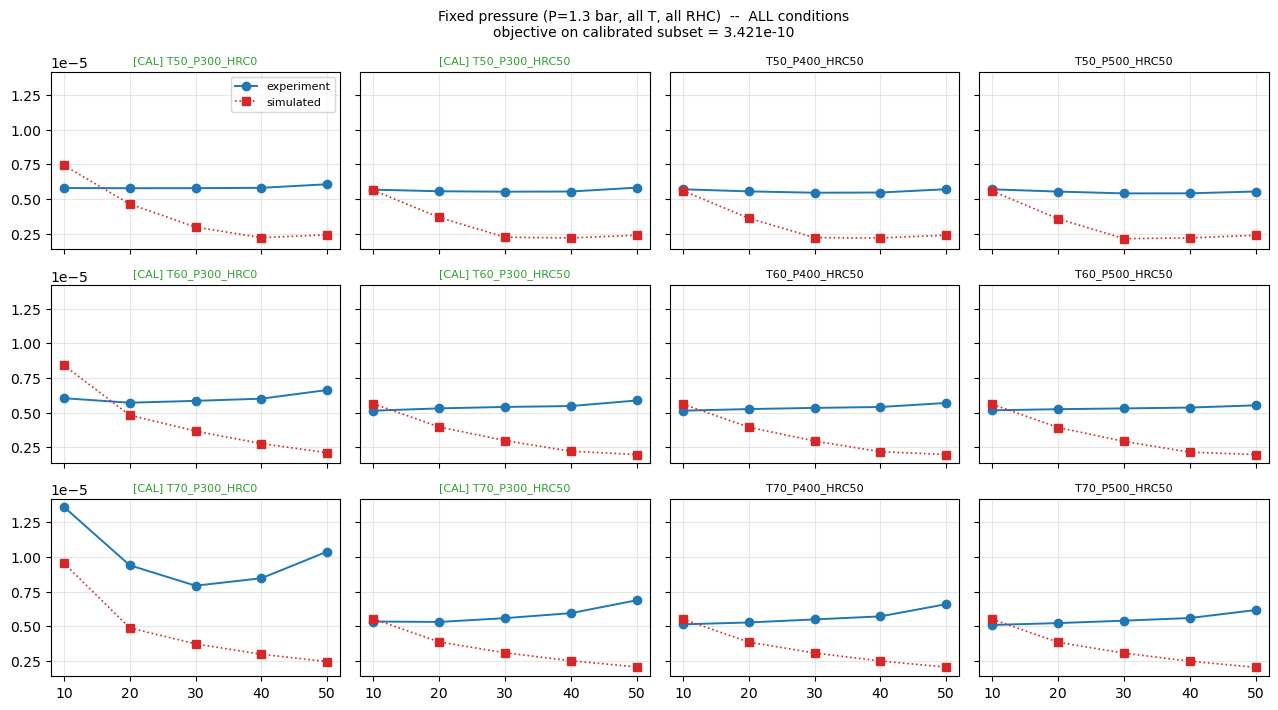

In [13]:
plot_scenario_fit("fixed_pressure")


### Scenario: `fixed_temperature`

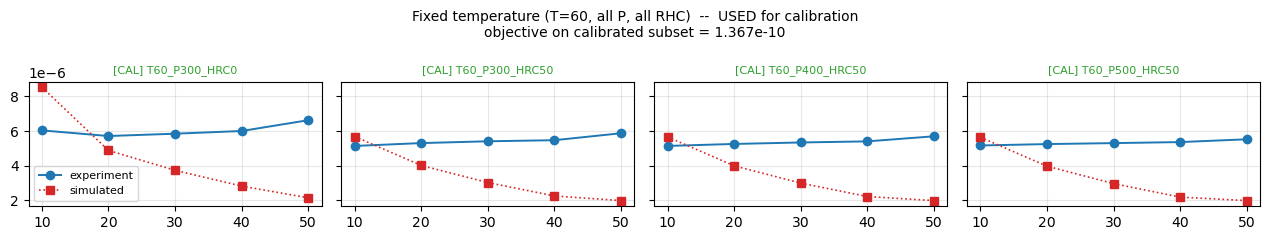

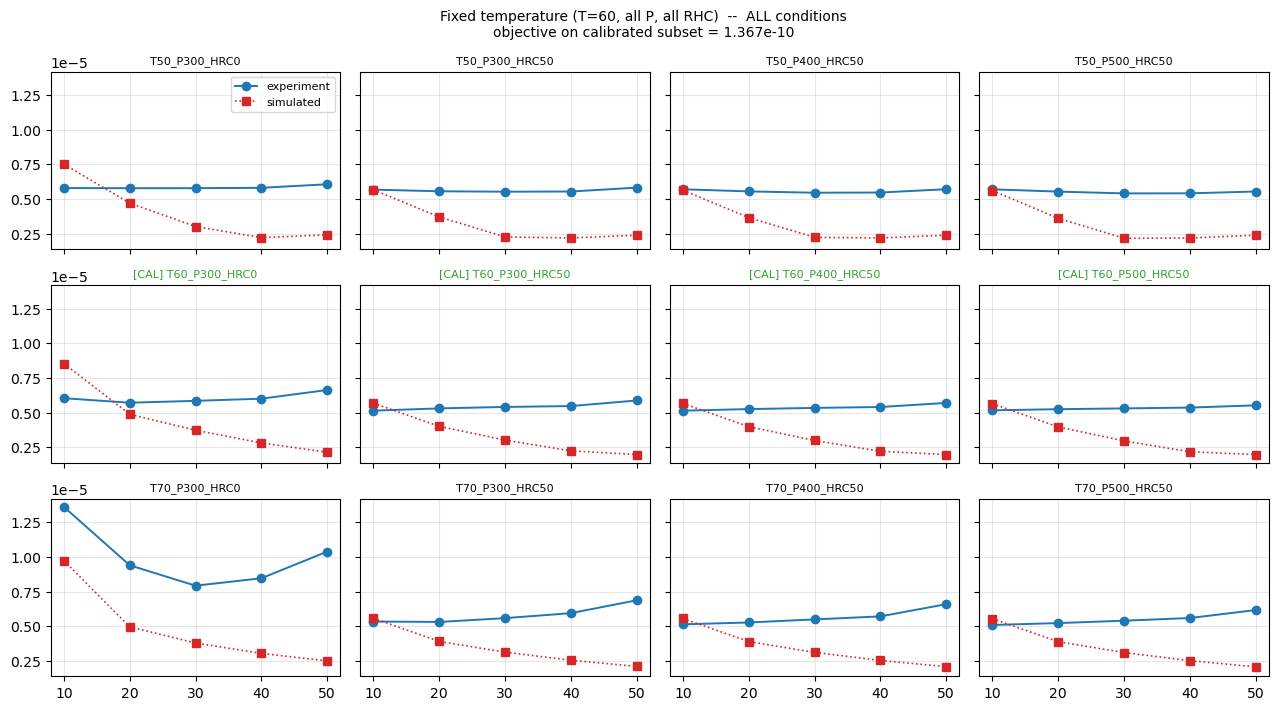

In [14]:
plot_scenario_fit("fixed_temperature")


### Scenario: `all_data`

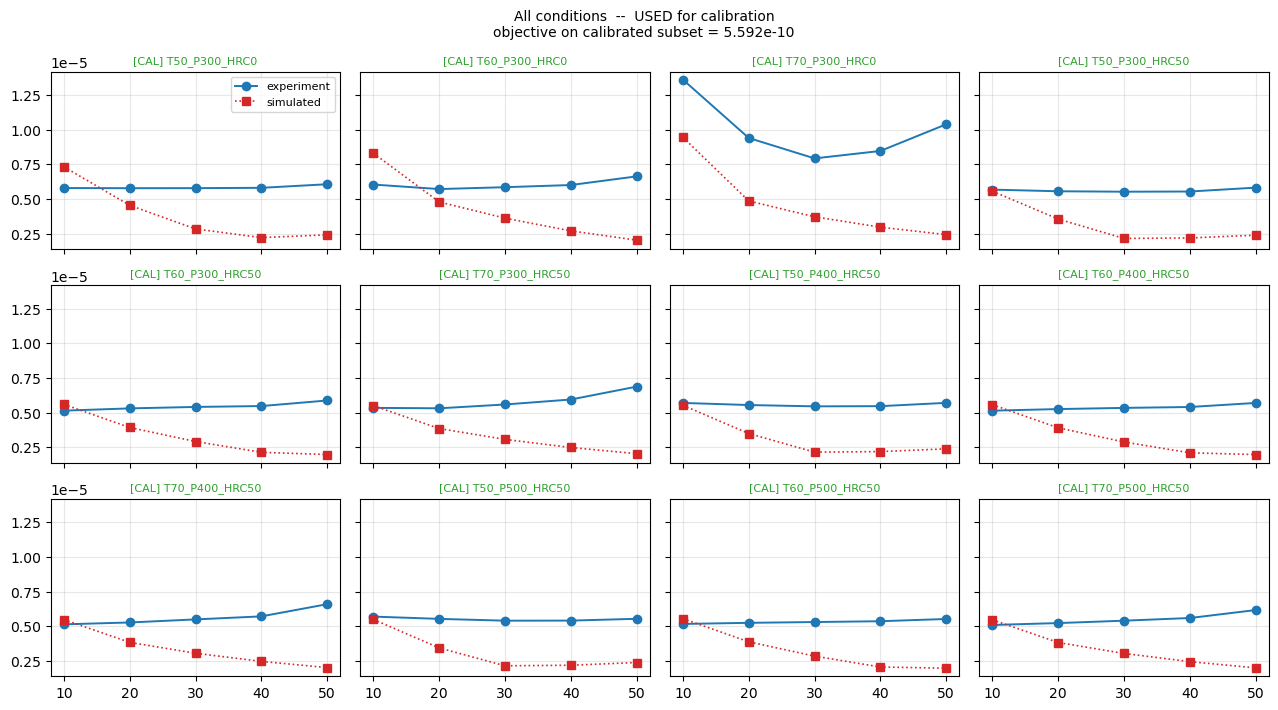

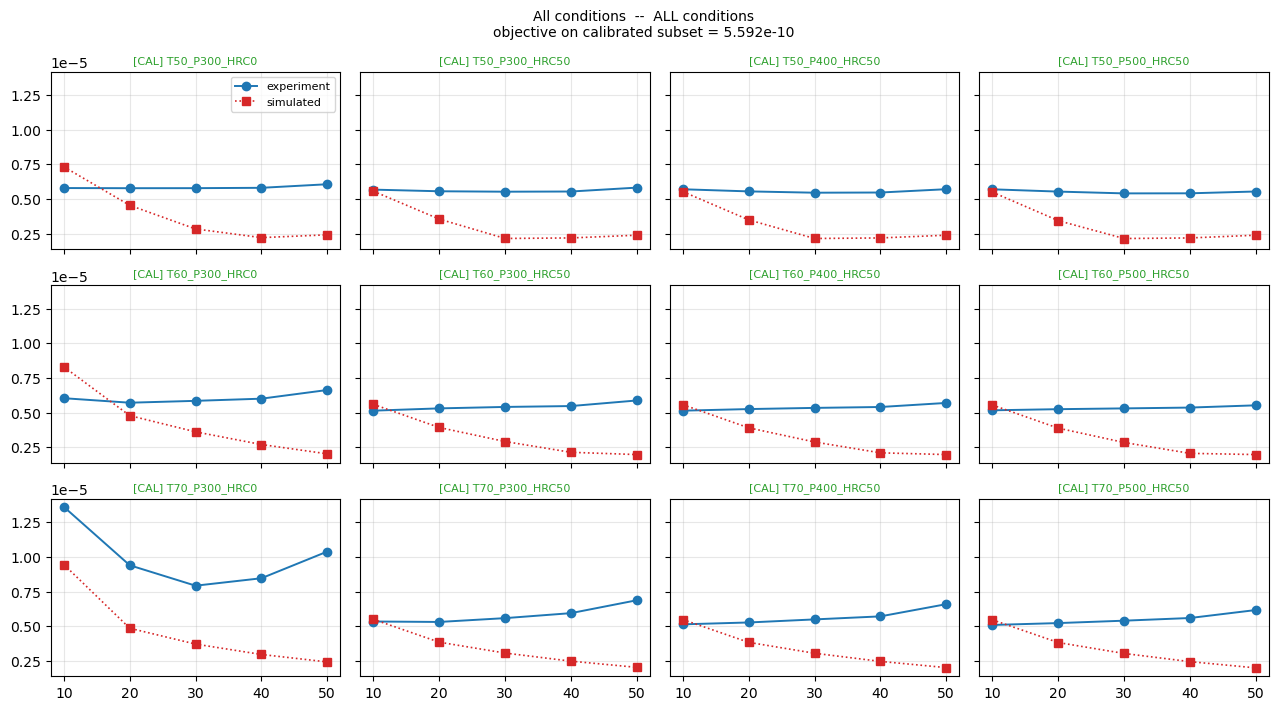

In [15]:
plot_scenario_fit("all_data")


## Residual heatmap
Bright cells in columns *not* enclosed by a white box show that the scenario generalised; dark cells outside the boxes are the operating conditions where the calibrated parameters fail.

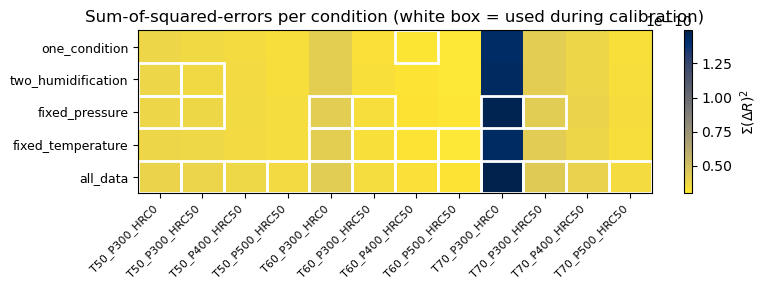

In [16]:
# Residual heatmap: scenarios (rows) x conditions (columns).
all_cond_keys = list(hfrdata_exp.keys())
n_scen = len(results)
residual_matrix = np.full((n_scen, len(all_cond_keys)), np.nan)
for i_scen, (name, info) in enumerate(results.items()):
    for i_cond, cond_key in enumerate(all_cond_keys):
        if cond_key not in info["sim_all"]:
            continue
        r_sim = np.array(info["sim_all"][cond_key])
        r_exp = _experimental_hfr(cond_key)
        residual_matrix[i_scen, i_cond] = float(np.sum((r_sim - r_exp) ** 2))

fig, ax = plt.subplots(figsize=(max(8, len(all_cond_keys) * 0.5), 0.5 + 0.5 * n_scen))
im = ax.imshow(residual_matrix, aspect="auto", cmap="cividis_r")
ax.set_yticks(range(n_scen)); ax.set_yticklabels(list(results.keys()), fontsize=9)
ax.set_xticks(range(len(all_cond_keys)))
ax.set_xticklabels(all_cond_keys, rotation=45, ha="right", fontsize=8)
for i_scen, (name, info) in enumerate(results.items()):
    cal_set = set(info["calibrated_keys"])
    for i_cond, cond_key in enumerate(all_cond_keys):
        if cond_key in cal_set:
            ax.add_patch(plt.Rectangle((i_cond - 0.5, i_scen - 0.5), 1, 1,
                                       fill=False, edgecolor="white", linewidth=2))
ax.set_title("Sum-of-squared-errors per condition (white box = used during calibration)")
fig.colorbar(im, ax=ax, label=r"$\Sigma(\Delta R)^2$")
plt.tight_layout()
plt.show()
